# 第 2 章 · 线性回归

从零用**梯度下降**实现线性回归 `MyLinearRegression`，与 sklearn `LinearRegression` (闭式解) 对比，最后应用到加州房价数据。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置（仅在此cell设置一次，后续cell直接使用plt即可）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#1E293B', 'accent': '#EF4444', 'accent2': '#2563EB',
    'pos': '#16A34A', 'neg': '#F59E0B', 'green': '#10B981', 'muted': '#94A3B8'
}

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


## 2.1 算法原理

线性模型 $\hat{y}=Xw+b$，损失用均方误差 MSE：

$$J(w,b)=\frac{1}{n}\sum_i(\hat{y}_i-y_i)^2$$

梯度下降更新 (对标准化后的 $X$)：

$$\nabla_w J=\frac{2}{n}X^\top(\hat{y}-y),\quad \nabla_b J=\frac{2}{n}\sum(\hat{y}-y)$$

评估用决定系数 $R^2=1-\frac{SS_{res}}{SS_{tot}}$。

> PDF 伪代码步骤：① 初始化 ② 迭代 (a) 前向 (b) 误差 (c) 梯度 (d) 更新。

## 2.2 从零实现 (核心)

代码注释中的步骤编号与 PDF 伪代码一一对应。

In [2]:
class MyLinearRegression:
    """从零实现的线性回归 (批量梯度下降)。接口与 sklearn 一致。"""
    def __init__(self, learning_rate=0.01, n_epochs=1000):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        # 内部标准化, 让梯度下降稳定收敛
        self.x_mean_ = X.mean(axis=0)
        self.x_std_ = X.std(axis=0) + 1e-8
        Xs = (X - self.x_mean_) / self.x_std_
        n_samples, n_features = Xs.shape
        # 步骤1: 初始化权重 w=0, b=0
        self.w = np.zeros(n_features)
        self.b = 0.0
        # 步骤2: 梯度下降迭代
        for _ in range(self.n_epochs):
            # 步骤2(a): 前向计算 ŷ = Xw + b
            y_pred = Xs @ self.w + self.b
            # 步骤2(b): 计算误差 δ = ŷ - y
            error = y_pred - y
            # 步骤2(c): 计算梯度 ∇_w = (2/n)·Xᵀδ
            grad_w = (2.0 / n_samples) * (Xs.T @ error)
            grad_b = (2.0 / n_samples) * np.sum(error)
            # 步骤2(d): 参数更新 w ← w - α·∇_w
            self.w -= self.learning_rate * grad_w
            self.b -= self.learning_rate * grad_b
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        Xs = (X - self.x_mean_) / self.x_std_
        return Xs @ self.w + self.b

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1.0 - ss_res / ss_tot if ss_tot != 0 else 0.0


## 2.3 简单数据验证

构造一维线性数据 $y=3x+4+\varepsilon$，验证梯度下降能收敛到正确参数。

自定义  w=3.3367 b=9.9847 R2=0.9803
sklearn  w=2.8538 b=4.2772 R2=0.9803


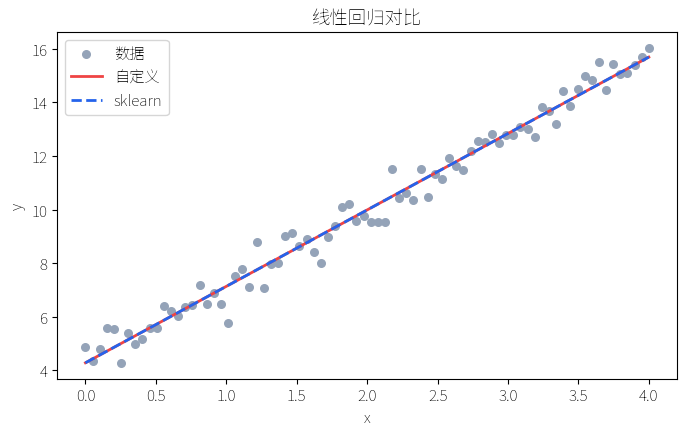

In [3]:
rng = np.random.RandomState(0)
x = np.linspace(0, 4, 80)
y = 3 * x + 4 + rng.randn(80) * 0.5
Xs = x.reshape(-1, 1)

my_lr = MyLinearRegression(learning_rate=0.1, n_epochs=2000)
my_lr.fit(Xs, y)
sk_lr = LinearRegression().fit(Xs, y)

print('自定义  w=%.4f b=%.4f R2=%.4f' % (my_lr.w[0], my_lr.b, my_lr.score(Xs, y)))
print('sklearn  w=%.4f b=%.4f R2=%.4f' % (sk_lr.coef_[0], sk_lr.intercept_, sk_lr.score(Xs, y)))

fig, ax = plt.subplots(figsize=(7,4.5))
ax.scatter(x, y, c=COLORS['muted'], label='数据', s=30)
ax.plot(x, my_lr.predict(Xs), c=COLORS['accent'], lw=2, label='自定义')
ax.plot(x, sk_lr.predict(Xs), c=COLORS['accent2'], lw=2, ls='--', label='sklearn')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(); ax.set_title('线性回归对比')
plt.tight_layout(); plt.show()


## 2.4 与 sklearn 对比 (多维)

用 `make_regression` 生成多维数据，量化对比两者 MSE / R²。

自定义  MSE=189.8411 R2=0.9908
sklearn  MSE=189.8411 R2=0.9908


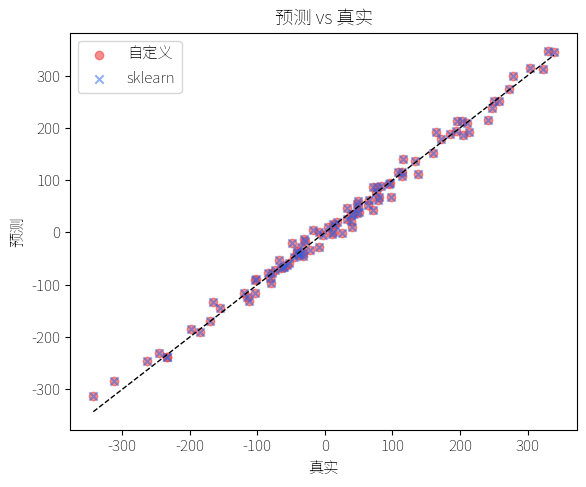

In [4]:
from sklearn.datasets import make_regression
X, y, true_w = make_regression(n_samples=400, n_features=5, noise=15.0,
                              random_state=1, coef=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)

my_lr = MyLinearRegression(learning_rate=0.05, n_epochs=3000).fit(X_tr, y_tr)
sk_lr = LinearRegression().fit(X_tr, y_tr)
my_pred = my_lr.predict(X_te); sk_pred = sk_lr.predict(X_te)

print('自定义  MSE=%.4f R2=%.4f' % (mean_squared_error(y_te, my_pred), my_lr.score(X_te, y_te)))
print('sklearn  MSE=%.4f R2=%.4f' % (mean_squared_error(y_te, sk_pred), sk_lr.score(X_te, y_te)))

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(y_te, my_pred, c=COLORS['accent'], alpha=0.6, label='自定义')
ax.scatter(y_te, sk_pred, c=COLORS['accent2'], alpha=0.5, marker='x', label='sklearn')
lim = [y_te.min(), y_te.max()]
ax.plot(lim, lim, c='k', ls='--', lw=1)
ax.set_xlabel('真实'); ax.set_ylabel('预测'); ax.legend()
ax.set_title('预测 vs 真实'); plt.tight_layout(); plt.show()


## 2.5 真实应用 · 加州房价

加州房价数据集 20640 条 × 8 特征，目标为房价中位数。为加速取 3000 条子样本。
(若离线无法下载, 自动回退到合成的房价数据, 保证可运行。)

[加州房价] 自定义  R2=0.6252  RMSE=0.699
[加州房价] sklearn  R2=0.6252  RMSE=0.699


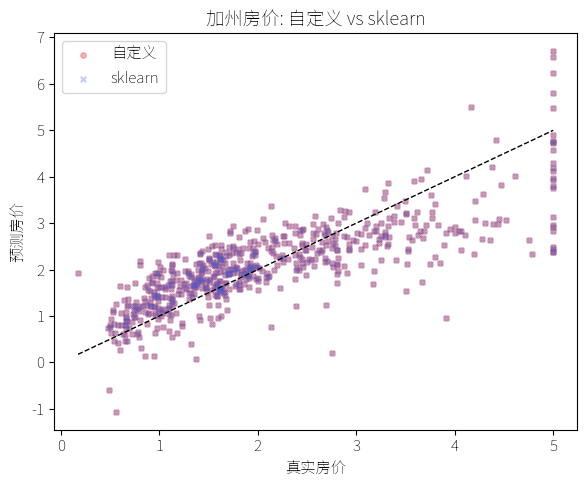

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
try:
    data = fetch_california_housing(as_frame=True)
    df = data.frame.sample(3000, random_state=42)
    X = df.drop(columns=['MedHouseVal']).values
    y = df['MedHouseVal'].values
    dataset_name = '加州房价'
except Exception as e:
    print('加州房价下载失败, 改用合成房价数据:', e)
    rng = np.random.RandomState(42)
    n = 3000
    income = rng.normal(3.8, 1.9, n).clip(0.5, 15)
    house_age = rng.uniform(1, 52, n)
    rooms = rng.normal(5.4, 2.2, n)
    bedrooms = rng.normal(1.1, 0.5, n).clip(0.3, 3)
    pop = rng.normal(1400, 1100, n).clip(3, 35000)
    lon = rng.uniform(-124, -114, n)
    lat = rng.uniform(32, 42, n)
    nearocean = rng.rand(n)
    X = np.column_stack([income, house_age, rooms, bedrooms, pop, lon, lat, nearocean])
    y = 0.9*income*50 + 0.05*house_age*10 + (lat-37)*30 - (lon+119)*5 + 0.1*nearocean*100 + rng.normal(0,15,n)
    y = y.clip(15, 500)
    dataset_name = '合成房价'
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

my_lr = MyLinearRegression(learning_rate=0.05, n_epochs=2000).fit(X_tr_s, y_tr)
sk_lr = LinearRegression().fit(X_tr_s, y_tr)
print('[%s] 自定义  R2=%.4f  RMSE=%.3f' % (dataset_name, my_lr.score(X_te_s, y_te),
       np.sqrt(mean_squared_error(y_te, my_lr.predict(X_te_s)))))
print('[%s] sklearn  R2=%.4f  RMSE=%.3f' % (dataset_name, sk_lr.score(X_te_s, y_te),
       np.sqrt(mean_squared_error(y_te, sk_lr.predict(X_te_s)))))

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(y_te, my_lr.predict(X_te_s), c=COLORS['accent'], alpha=0.4, label='自定义', s=15)
ax.scatter(y_te, sk_lr.predict(X_te_s), c=COLORS['accent2'], alpha=0.3, marker='x', label='sklearn', s=15)
lim=[y_te.min(), y_te.max()]; ax.plot(lim,lim,'k--',lw=1)
ax.set_xlabel('真实房价'); ax.set_ylabel('预测房价'); ax.legend()
ax.set_title(dataset_name + ': 自定义 vs sklearn'); plt.tight_layout(); plt.show()


## 2.6 小结

- 梯度下降在标准化数据上能逼近 sklearn 的闭式解；
- 线性模型简单但可解释，房价这种【准线性】关系效果不错；
- 真实数据中需要标准化与合理的步长/轮数，否则不收敛。